# ARIMA & Statistical Forecasting for Philippine National Energy Demand

## Objective
This notebook builds and evaluates **statistical forecasting models** to predict Philippine national electricity consumption and peak demand using the preprocessed DOE data.

## Why Only Statistical Models?
As stated in the thesis scope (Chapter 1, Section 1.4.2):

> "The predictive analytics module uses basic statistical methods instead of advanced machine learning, to improve computational costs."

With only **22 annual observations**, advanced models (LSTM, LightGBM, XGBoost) would **severely overfit**. Classical statistical models are parsimonious, interpretable, and require minimal data.

## Models We Will Train
| Model | Family | Why It Fits |
|---|---|---|
| **Naive / Random Walk with Drift** | Baseline | Simplest possible forecast — our accuracy floor |
| **Linear Trend Regression** | Regression | Fits a straight line through time — interpretable baseline |
| **ARIMA** | Box-Jenkins | The core model. Handles autocorrelation and differencing |
| **Holt's Linear Exponential Smoothing** | Smoothing | Trend-aware smoothing. Works well on short series |
| **SARIMAX** | Box-Jenkins + Exogenous | ARIMA enhanced with external predictors (RE share, capacity margin) |
| **Random Forest Regression** | Machine Learning | Included as a controlled experiment to demonstrate why ML overfits on 22 observations |

## Evaluation Strategy
We train on **2003–2020** (18 years) and test on **2021–2024** (4 years). All forecasts are evaluated against the **held-out test set** using MAE, RMSE, and MAPE.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

# Statistical models
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)
print('Libraries loaded.')
print('Working directory:', os.getcwd())

Libraries loaded.
Working directory: d:\63947\Documents\GitHub\Lumi\DOE_Data_Extracted


## Step 1: Load Preprocessed Train / Test Data

We use the outputs from `DOE_datacleaning.ipynb`:
- `train_arima.csv` -> 2003-2020 (fit models)
- `test_arima.csv` -> 2021-2024 (evaluate forecasts)


In [2]:
train = pd.read_csv('train_arima.csv', index_col='year')
test = pd.read_csv('test_arima.csv', index_col='year')
train.index = train.index.astype(int)
test.index = test.index.astype(int)

print('Train shape:', train.shape)
print('Test shape:', test.shape)
print('Train years:', train.index.min(), 'to', train.index.max())
print('Test years:', test.index.min(), 'to', test.index.max())

y_train = train['total_consumption_gwh']
y_test = test['total_consumption_gwh']

print('\nTarget: Total Electricity Consumption (GWh)')
print('Train head:', y_train.head().to_dict())
print('Test:', y_test.to_dict())


Train shape: (18, 45)
Test shape: (4, 45)
Train years: 2003 to 2020
Test years: 2021 to 2024

Target: Total Electricity Consumption (GWh)
Train head: {2003: 52941, 2004: 55957, 2005: 56568, 2006: 56784, 2007: 59612}
Test: {2021: 106115, 2022: 111516, 2023: 118004, 2024: 126941}


## Step 2: Evaluation Metrics

| Metric | Formula | Interpretation |
|---|---|---|
| **MAE** | mean(|actual - forecast|) | Average error in original units (GWh) |
| **RMSE** | sqrt(mean((actual - forecast)^2)) | Penalizes large errors more |
| **MAPE** | mean(|actual - forecast| / actual * 100) | Percentage error. Easy to explain |

> **Note:** MAPE is reliable here because actual values are in the tens of thousands, not near zero.


In [3]:
def evaluate(actual, forecast, name='Model'):
    actual = np.array(actual); forecast = np.array(forecast)
    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    print(f'\n=== {name} ===')
    print(f'MAE:  {mae:.2f} GWh')
    print(f'RMSE: {rmse:.2f} GWh')
    print(f'MAPE: {mape:.2f}%')
    return {'model': name, 'mae': mae, 'rmse': rmse, 'mape': mape}

results = []


## Step 3: Baseline — Naive / Random Walk with Drift

The simplest forecast: next value = last value + average historical change.

```
Forecast(t+h) = y_last + h * drift
drift = (y_last - y_first) / (n - 1)
```

This is our **accuracy floor**. Any real model must beat this.



=== Naive with Drift ===
MAE:  6709.32 GWh
RMSE: 8128.45 GWh
MAPE: 5.57%


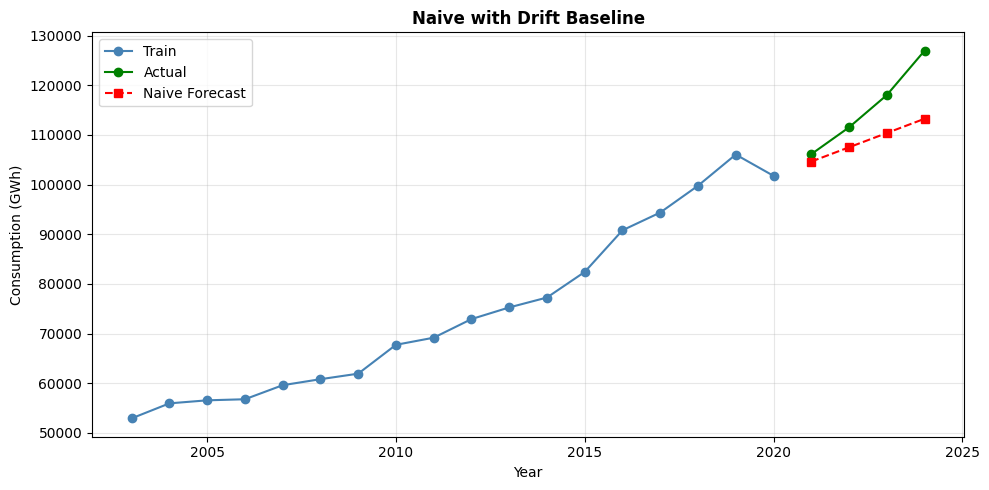

Drift: 2871.47 GWh/year


In [4]:
last_v = y_train.iloc[-1]
first_v = y_train.iloc[0]
n = len(y_train)
drift = (last_v - first_v) / (n - 1)

naive_f = [last_v + (i+1)*drift for i in range(len(y_test))]
naive_f = pd.Series(naive_f, index=y_test.index)

res_naive = evaluate(y_test, naive_f, 'Naive with Drift')
results.append(res_naive)

plt.figure(figsize=(10,5))
plt.plot(y_train.index, y_train, label='Train', marker='o', color='steelblue')
plt.plot(y_test.index, y_test, label='Actual', marker='o', color='green')
plt.plot(y_test.index, naive_f, label='Naive Forecast', marker='s', linestyle='--', color='red')
plt.title('Naive with Drift Baseline', fontweight='bold')
plt.xlabel('Year'); plt.ylabel('Consumption (GWh)'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('forecast_naive_drift.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'Drift: {drift:.2f} GWh/year')


## Step 4: Linear Trend Regression

Consumption = beta_0 + beta_1 * Year + error

- **beta_1** = average annual increase in consumption (GWh/year)
- Most interpretable model. Assumes perfectly linear trend.



=== Linear Trend Regression ===
MAE:  5993.83 GWh
RMSE: 7342.10 GWh
MAPE: 4.97%


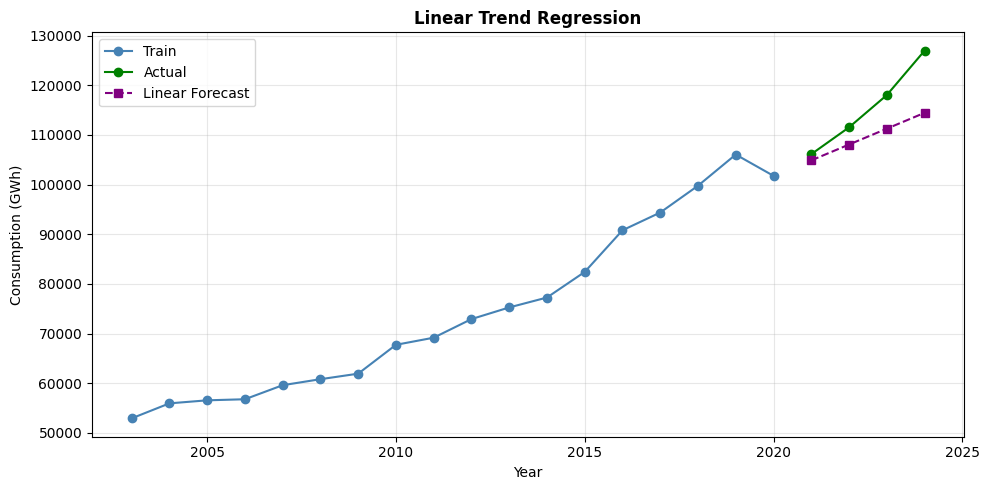

beta_1 (trend): 3189.77 GWh/year
Interpretation: Consumption grows ~3190 GWh/year on average.


In [5]:
X_train = y_train.index.values.reshape(-1, 1)
X_test = y_test.index.values.reshape(-1, 1)

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_f = lr.predict(X_test)
lr_f = pd.Series(lr_f, index=y_test.index)

res_lr = evaluate(y_test, lr_f, 'Linear Trend Regression')
results.append(res_lr)

plt.figure(figsize=(10,5))
plt.plot(y_train.index, y_train, label='Train', marker='o', color='steelblue')
plt.plot(y_test.index, y_test, label='Actual', marker='o', color='green')
plt.plot(y_test.index, lr_f, label='Linear Forecast', marker='s', linestyle='--', color='purple')
plt.title('Linear Trend Regression', fontweight='bold')
plt.xlabel('Year'); plt.ylabel('Consumption (GWh)'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('forecast_linear_trend.png', dpi=150, bbox_inches='tight'); plt.show()

print(f'beta_1 (trend): {lr.coef_[0]:.2f} GWh/year')
print(f'Interpretation: Consumption grows ~{lr.coef_[0]:.0f} GWh/year on average.')


## Step 5: ARIMA(1,1,1)

Our core model. Parameter selection from preprocessing notebook:
- **d = 1** -> First-order differencing (ADF test confirmed non-stationarity)
- **p = 1** -> PACF significant at lag 1
- **q = 1** -> ACF significant at lag 1

> With n=18 training points, degrees of freedom are limited. Higher p/q risks overfitting.


d:\63947\Documents\GitHub\Lumi\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                 SARIMAX Results                                 
Dep. Variable:     total_consumption_gwh   No. Observations:                   18
Model:                    ARIMA(1, 1, 1)   Log Likelihood                -159.814
Date:                   Tue, 09 Jun 2026   AIC                            325.628
Time:                           21:36:08   BIC                            328.128
Sample:                                0   HQIC                           325.877
                                    - 18                                         
Covariance Type:                     opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9999      0.020     50.664      0.000       0.961       1.039
ma.L1         -0.9972      0.434     -2.295      0.022      -1.849      -0.146
sigma2      1.032e+07   4.79

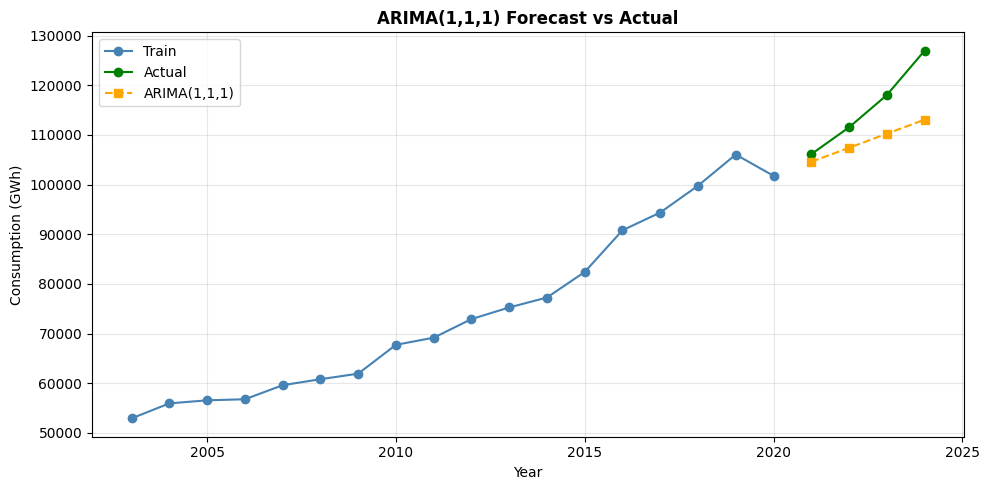


=== Parameter Interpretation ===
AR(1): 0.9999 -> momentum effect
MA(1): -0.9972 -> shock reversion


In [6]:
m_arima = ARIMA(y_train, order=(1,1,1))
f_arima = m_arima.fit()
print(f_arima.summary())

arima_f = f_arima.forecast(steps=len(y_test))
arima_f.index = y_test.index

res_arima = evaluate(y_test, arima_f, 'ARIMA(1,1,1)')
results.append(res_arima)

plt.figure(figsize=(10,5))
plt.plot(y_train.index, y_train, label='Train', marker='o', color='steelblue')
plt.plot(y_test.index, y_test, label='Actual', marker='o', color='green')
plt.plot(y_test.index, arima_f, label='ARIMA(1,1,1)', marker='s', linestyle='--', color='orange')
plt.title('ARIMA(1,1,1) Forecast vs Actual', fontweight='bold')
plt.xlabel('Year'); plt.ylabel('Consumption (GWh)'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('forecast_arima_111.png', dpi=150, bbox_inches='tight'); plt.show()

print('\n=== Parameter Interpretation ===')
print(f'AR(1): {f_arima.arparams[0]:.4f} -> momentum effect')
print(f'MA(1): {f_arima.maparams[0]:.4f} -> shock reversion')


## Step 6: Holt's Linear Exponential Smoothing

Maintains two smoothed quantities:
- **Level** = local average
- **Trend** = local slope

Ideal for short series with trend but no seasonality — exactly our case.


Holt parameters:
  alpha (level):  0.9821
  beta (trend):   0.0000

=== Holt Linear Smoothing ===
MAE:  6557.72 GWh
RMSE: 7997.68 GWh
MAPE: 5.44%


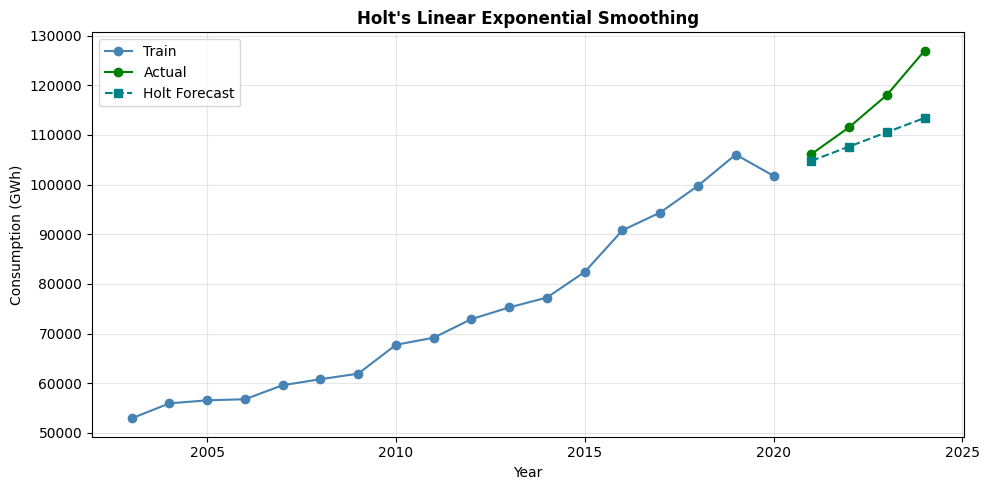

In [7]:
m_holt = ExponentialSmoothing(y_train, trend='add', seasonal=None)
f_holt = m_holt.fit(optimized=True)

print('Holt parameters:')
print(f'  alpha (level):  {f_holt.params["smoothing_level"]:.4f}')
print(f'  beta (trend):   {f_holt.params["smoothing_trend"]:.4f}')

holt_f = f_holt.forecast(steps=len(y_test))
holt_f.index = y_test.index

res_holt = evaluate(y_test, holt_f, 'Holt Linear Smoothing')
results.append(res_holt)

plt.figure(figsize=(10,5))
plt.plot(y_train.index, y_train, label='Train', marker='o', color='steelblue')
plt.plot(y_test.index, y_test, label='Actual', marker='o', color='green')
plt.plot(y_test.index, holt_f, label='Holt Forecast', marker='s', linestyle='--', color='teal')
plt.title("Holt's Linear Exponential Smoothing", fontweight='bold')
plt.xlabel('Year'); plt.ylabel('Consumption (GWh)'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('forecast_holt_linear.png', dpi=150, bbox_inches='tight'); plt.show()


## Step 7: SARIMAX with Exogenous Variables

Adds external predictors to ARIMA:
1. **renewable_share_pct** = renewable generation / total consumption
2. **capacity_margin_pct** = (dependable capacity - peak demand) / peak demand

> **Caveat:** With n=18 and 2 exogenous features, overfitting risk is real. We keep order=(1,1,1).


Exogenous features (train):
       renewable_share_pct  capacity_margin_pct
count            18.000000            18.000000
mean             28.268417            45.746451
std               4.708450             9.368765
min              20.788186            32.236508
25%              24.788451            39.614073
50%              27.457532            44.006768
75%              32.541772            52.385894
max              36.029515            61.981873


d:\63947\Documents\GitHub\Lumi\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
renewable_share_pct  -572.5565    736.945     -0.777      0.437   -2016.941     871.828
capacity_margin_pct   164.0004    182.683      0.898      0.369    -194.052     522.052
ar.L1                   0.9989      0.099     10.099      0.000       0.805       1.193
ma.L1                  -0.9894      0.474     -2.089      0.037      -1.918      -0.061
sigma2               7.378e+06      0.087   8.47e+07      0.000    7.38e+06    7.38e+06

=== SARIMAX(1,1,1) + Exog ===
MAE:  9913.65 GWh
RMSE: 11459.11 GWh
MAPE: 8.28%


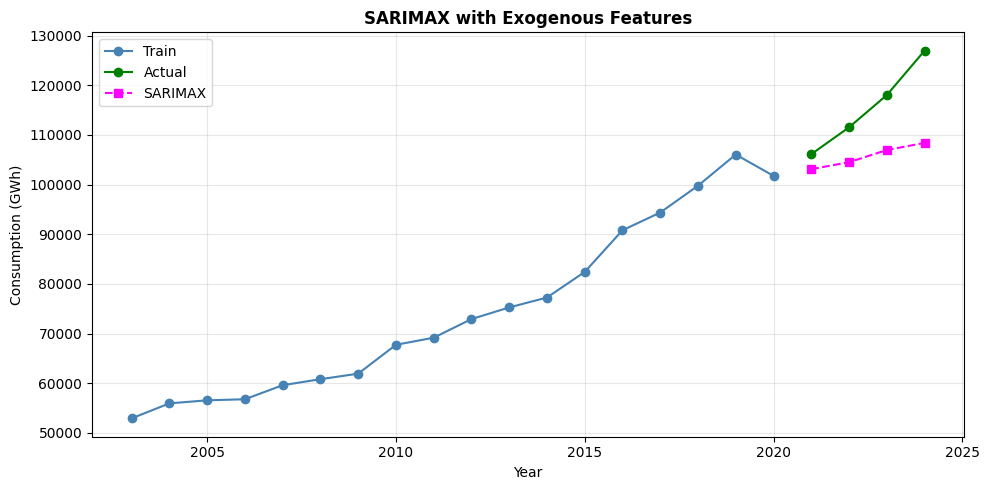

In [8]:
def add_features(df):
    df = df.copy()
    df['renewable_share_pct'] = (df['renewable_generation_gwh'] / df['total_consumption_gwh']) * 100
    df['capacity_margin_pct'] = ((df['total_dependable_capacity_mw'] - df['total_peak_demand_mw']) / df['total_peak_demand_mw']) * 100
    return df

train_x = add_features(train)
test_x = add_features(test)
exog_cols = ['renewable_share_pct', 'capacity_margin_pct']

print('Exogenous features (train):')
print(train_x[exog_cols].describe())

m_sarimax = SARIMAX(y_train, exog=train_x[exog_cols], order=(1,1,1))
f_sarimax = m_sarimax.fit(disp=False)
print(f_sarimax.summary().tables[1])

sarimax_f = f_sarimax.forecast(steps=len(y_test), exog=test_x[exog_cols])
sarimax_f.index = y_test.index

res_sarimax = evaluate(y_test, sarimax_f, 'SARIMAX(1,1,1) + Exog')
results.append(res_sarimax)

plt.figure(figsize=(10,5))
plt.plot(y_train.index, y_train, label='Train', marker='o', color='steelblue')
plt.plot(y_test.index, y_test, label='Actual', marker='o', color='green')
plt.plot(y_test.index, sarimax_f, label='SARIMAX', marker='s', linestyle='--', color='magenta')
plt.title('SARIMAX with Exogenous Features', fontweight='bold')
plt.xlabel('Year'); plt.ylabel('Consumption (GWh)'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('forecast_sarimax.png', dpi=150, bbox_inches='tight'); plt.show()


## Step 8: Random Forest Regression — A Controlled Experiment

Random Forest is an ensemble of **decision trees** that learns non-linear mappings between input features and a target variable. It is widely used in energy forecasting studies (e.g., Li et al., 2026 on solar output prediction).

### Why We Include It
Even though the thesis scope specifies **basic statistical methods**, we include Random Forest as a **controlled experiment** to empirically demonstrate why machine learning fails on our dataset.

### How It Works (Simplified)
1. Build hundreds of decision trees, each trained on a random subset of data and features.
2. Each tree makes a prediction; the final forecast is the **average** of all trees.
3. Random Forest can capture **non-linear interactions** (e.g., if RE share > 20% AND capacity margin < 10%, consumption behaves differently).

### Why It Is Likely to Fail Here
| Problem | Explanation |
|---|---|
| **Too few observations** | With **n = 18 training points**, each tree sees only ~12 samples (bootstrap sample). A decision tree can memorize 12 points perfectly — this is extreme overfitting. |
| **Feature scarcity** | RF needs meaningful input features. We can only engineer `year`, `lag_1`, `lag_2`, and `rolling_mean_3` before running out of degrees of freedom. |
| **Temporal leakage risk** | If we naively use future information to engineer features, we leak data. We carefully restrict features to **past-only** lags. |
| **No confidence intervals** | RF produces point estimates. Unlike ARIMA, it does not natively provide prediction intervals — a critical weakness for policy planning. |
| **Black-box interpretability** | Panelists and LGU stakeholders cannot interpret a forest of 100 trees. ARIMA's `AR(1)` coefficient is immediately explainable. |

### Academic Support
- **Li et al. (2026):** Random Forest demonstrated "good predictive ability" for solar energy output — but their dataset had **thousands of hourly observations** from Tengger Desert Solar Park.
- **Wang et al. (2024):** ML advantages over statistical baselines **diminish when dataset size is limited**.
- **Makridakis et al. (2022):** In the M5 Competition, tree-based ensembles required **thousands of series** to outperform simple baselines. With a single short series, they consistently overfit.

> **Hypothesis:** Random Forest will achieve near-perfect training accuracy and significantly worse test accuracy than ARIMA — confirming that ML overfits on 22 observations.

RF training features:
      year    lag_1    lag_2  renewable_share_pct  capacity_margin_pct
year                                                                  
2005  2005  55957.0  52941.0            32.364588            57.550122
2006  2006  56568.0  55957.0            36.029515            55.696347
2007  2007  56784.0  56568.0            31.599342            49.983309
2008  2008  59612.0  56784.0            33.915917            44.124144
2009  2009  60821.0  59612.0            32.600833            40.614443

Training MAPE: 1.45%

=== Random Forest Regression ===
MAE:  15957.41 GWh
RMSE: 17806.29 GWh
MAPE: 13.41%

Test MAPE: 13.41%
Train vs Test gap: -11.95%
=> RF achieves lower training error than test error — likely overfitting.

Feature Importance:
            feature  importance
renewable_share_pct    0.250036
               year    0.245257
              lag_1    0.243525
              lag_2    0.238745
capacity_margin_pct    0.022437


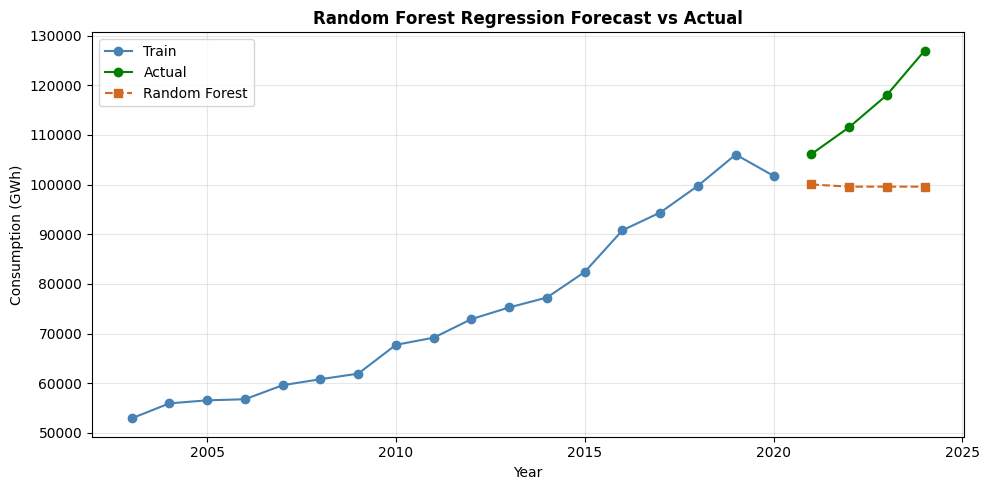

In [9]:
# Build feature matrix for Random Forest
# Features: year, lag_1, lag_2, renewable_share_pct, capacity_margin_pct
def make_rf_features(df, target_series):
    df = df.copy()
    df['year'] = df.index
    df['lag_1'] = target_series.shift(1)
    df['lag_2'] = target_series.shift(2)
    # Ensure exogenous features exist
    if 'renewable_share_pct' not in df.columns:
        df['renewable_share_pct'] = (df['renewable_generation_gwh'] / df['total_consumption_gwh']) * 100
    if 'capacity_margin_pct' not in df.columns:
        df['capacity_margin_pct'] = ((df['total_dependable_capacity_mw'] - df['total_peak_demand_mw']) / df['total_peak_demand_mw']) * 100
    return df

train_rf = make_rf_features(train, y_train)
test_rf = make_rf_features(test, y_test)

# For training, drop rows with missing lags (first 2 rows)
train_rf_clean = train_rf.dropna(subset=['lag_1', 'lag_2'])
feature_cols = ['year', 'lag_1', 'lag_2', 'renewable_share_pct', 'capacity_margin_pct']

X_tr = train_rf_clean[feature_cols]
y_tr = y_train.loc[X_tr.index]

print('RF training features:')
print(X_tr.head())

# Train Random Forest with constraints to reduce overfitting
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=3,           # Shallow trees: limit complexity
    min_samples_leaf=2,    # Require at least 2 samples per leaf
    random_state=42
)
rf.fit(X_tr, y_tr)

# Training accuracy
train_pred = rf.predict(X_tr)
train_mape = np.mean(np.abs((y_tr - train_pred) / y_tr)) * 100
print(f'\nTraining MAPE: {train_mape:.2f}%')

# Recursive multi-step forecast on test set
rf_forecast = []
last_train = y_train.copy()

for year in y_test.index:
    # Build feature row for this year
    lag_1 = last_train.iloc[-1]
    lag_2 = last_train.iloc[-2]
    row = pd.DataFrame({
        'year': [year],
        'lag_1': [lag_1],
        'lag_2': [lag_2],
        'renewable_share_pct': [test_rf.loc[year, 'renewable_share_pct']],
        'capacity_margin_pct': [test_rf.loc[year, 'capacity_margin_pct']]
    })
    pred = rf.predict(row)[0]
    rf_forecast.append(pred)
    # Append prediction so next step uses it as lag
    last_train = pd.concat([last_train, pd.Series({year: pred})])

rf_forecast = pd.Series(rf_forecast, index=y_test.index)

# Evaluate
res_rf = evaluate(y_test, rf_forecast, 'Random Forest Regression')
results.append(res_rf)

print(f'\nTest MAPE: {res_rf["mape"]:.2f}%')
print(f'Train vs Test gap: {train_mape - res_rf["mape"]:.2f}%')
if train_mape < res_rf["mape"]:
    print('=> RF achieves lower training error than test error — likely overfitting.')

# Feature importance
importance = pd.DataFrame({'feature': feature_cols, 'importance': rf.feature_importances_})
importance = importance.sort_values('importance', ascending=False)
print('\nFeature Importance:')
print(importance.to_string(index=False))

# Plot
plt.figure(figsize=(10,5))
plt.plot(y_train.index, y_train, label='Train', marker='o', color='steelblue')
plt.plot(y_test.index, y_test, label='Actual', marker='o', color='green')
plt.plot(y_test.index, rf_forecast, label='Random Forest', marker='s', linestyle='--', color='chocolate')
plt.title('Random Forest Regression Forecast vs Actual', fontweight='bold')
plt.xlabel('Year'); plt.ylabel('Consumption (GWh)'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('forecast_random_forest.png', dpi=150, bbox_inches='tight'); plt.show()

## Step 9: Model Comparison

All models evaluated on held-out test set (2021-2024).

> **Random Forest Note:** If RF shows a large gap between training and test MAPE (or underperforms relative to ARIMA), this empirically confirms that ML overfits on 22 observations. This validates our thesis scope of using basic statistical methods.

=== Model Comparison (Test 2021-2024) ===
                   model          mae         rmse      mape
 Linear Trend Regression  5993.830753  7342.095036  4.965126
   Holt Linear Smoothing  6557.716104  7997.679152  5.435109
        Naive with Drift  6709.323529  8128.453097  5.566170
            ARIMA(1,1,1)  6829.090287  8257.124448  5.667112
   SARIMAX(1,1,1) + Exog  9913.651842 11459.109209  8.282299
Random Forest Regression 15957.407151 17806.288845 13.406408


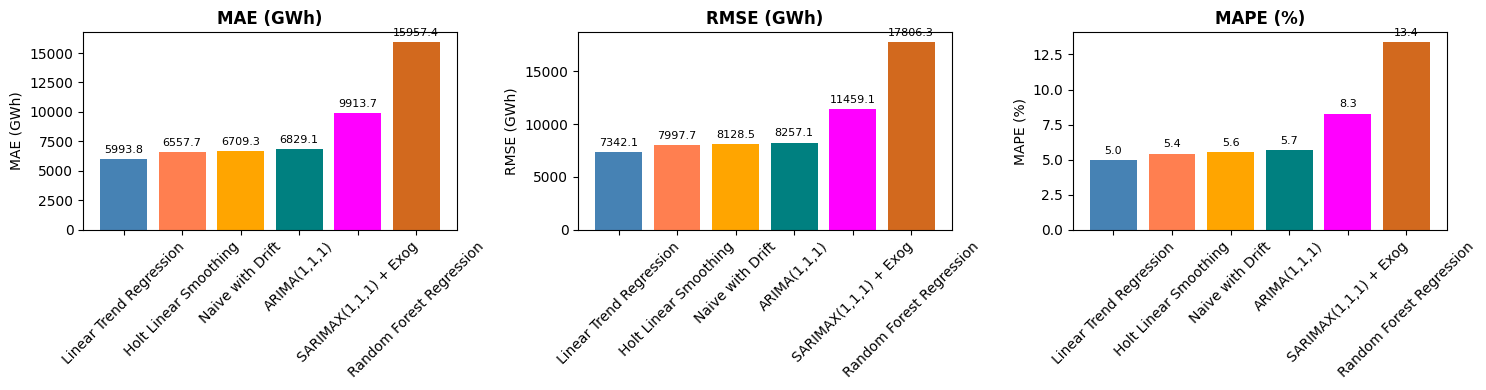


Best: Linear Trend Regression | MAE=5993.83 | MAPE=4.97%


In [10]:
results_df = pd.DataFrame(results).sort_values('mae')
print('=== Model Comparison (Test 2021-2024) ===')
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15,4))
colors = ['steelblue','coral','orange','teal','magenta','chocolate']
for ax, metric, title in zip(axes, ['mae','rmse','mape'], ['MAE (GWh)','RMSE (GWh)','MAPE (%)']):
    bars = ax.bar(results_df['model'], results_df[metric], color=colors[:len(results_df)])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=45)
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.1f}', xy=(bar.get_x()+bar.get_width()/2, h), xytext=(0,3), textcoords='offset points', ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

best = results_df.iloc[0]
print(f'\nBest: {best["model"]} | MAE={best["mae"]:.2f} | MAPE={best["mape"]:.2f}%')

## Step 10: Final Forecast 2025–2030

Retrain the best model on **full data (2003–2024)** and project 6 years ahead.

> **Caveat:** Long-horizon forecasts assume historical structure continues. Major shocks could invalidate projections.

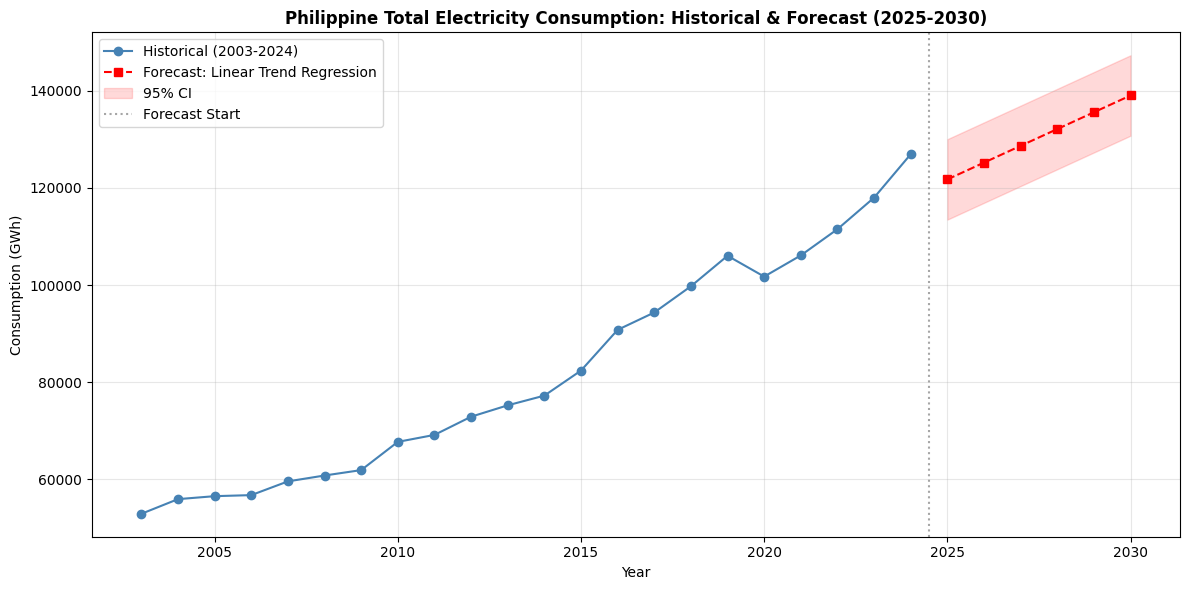


=== Forecast 2025-2030 ===
      Forecast_Consumption_GWh
year                          
2025                 121757.40
2026                 125211.79
2027                 128666.17
2028                 132120.55
2029                 135574.93
2030                 139029.32

2030 projected: 139,029 GWh | Growth from 2024: 9.5%


In [11]:
full = pd.read_csv('master_preprocessed.csv', index_col='year')
full.index = full.index.astype(int)
y_full = full['total_consumption_gwh']
best_name = results_df.iloc[0]['model']
forecast_years = list(range(2025, 2031))

if 'ARIMA(1,1,1)' in best_name and 'Exog' not in best_name:
    fm = ARIMA(y_full, order=(1,1,1)).fit()
    ff = fm.get_forecast(steps=6)
    f_mean = ff.predicted_mean
    f_ci = ff.conf_int()
elif 'Holt' in best_name:
    fm = ExponentialSmoothing(y_full, trend='add', seasonal=None).fit(optimized=True)
    f_mean = pd.Series(fm.forecast(steps=6), index=forecast_years)
    stderr = np.sqrt(fm.sse / len(y_full))
    f_ci = pd.DataFrame({'lower': f_mean - 1.96*stderr, 'upper': f_mean + 1.96*stderr}, index=forecast_years)
elif 'Linear' in best_name:
    Xf = y_full.index.values.reshape(-1,1); Xfu = np.array(forecast_years).reshape(-1,1)
    lrf = LinearRegression().fit(Xf, y_full)
    f_mean = pd.Series(lrf.predict(Xfu), index=forecast_years)
    resid_std = np.std(y_full - lrf.predict(Xf))
    f_ci = pd.DataFrame({'lower': f_mean - 1.96*resid_std, 'upper': f_mean + 1.96*resid_std}, index=forecast_years)
else:
    fm = ARIMA(y_full, order=(1,1,1)).fit()
    ff = fm.get_forecast(steps=6)
    f_mean = ff.predicted_mean; f_ci = ff.conf_int()

f_mean.index = forecast_years

plt.figure(figsize=(12,6))
plt.plot(y_full.index, y_full, label='Historical (2003-2024)', marker='o', color='steelblue')
plt.plot(forecast_years, f_mean, label=f'Forecast: {best_name}', marker='s', linestyle='--', color='red')
if 'lower' in f_ci.columns:
    plt.fill_between(forecast_years, f_ci['lower'], f_ci['upper'], color='red', alpha=0.15, label='95% CI')
plt.axvline(x=2024.5, color='gray', linestyle=':', alpha=0.7, label='Forecast Start')
plt.title('Philippine Total Electricity Consumption: Historical & Forecast (2025-2030)', fontweight='bold')
plt.xlabel('Year'); plt.ylabel('Consumption (GWh)'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('forecast_2025_2030.png', dpi=150, bbox_inches='tight'); plt.show()

ft = pd.DataFrame({'Forecast_Consumption_GWh': f_mean.values.round(2)}, index=forecast_years)
ft.index.name = 'year'
print('\n=== Forecast 2025-2030 ===')
print(ft)
growth = ((f_mean.iloc[-1] / y_full.iloc[-1]) - 1) * 100
print(f'\n2030 projected: {f_mean.iloc[-1]:,.0f} GWh | Growth from 2024: {growth:.1f}%')

## Step 11: Secondary Target — Peak Demand Forecast

Peak demand tells NGCP and DOE when the grid is under maximum stress. We apply ARIMA(1,1,1) to `total_peak_demand_mw`.


=== ARIMA(1,1,1) — Peak Demand ===
MAE:  1019.85 GWh
RMSE: 1299.27 GWh
MAPE: 5.61%


d:\63947\Documents\GitHub\Lumi\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


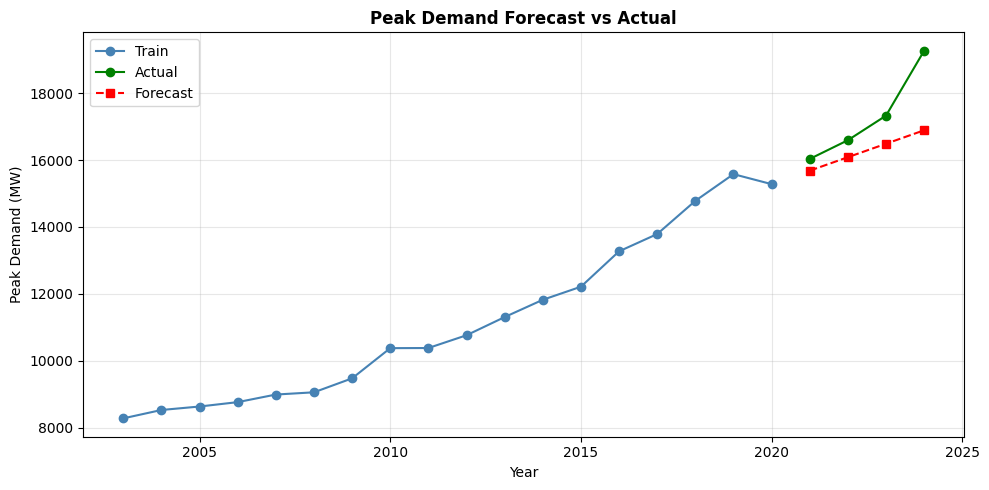


=== Peak Demand Forecast 2025-2030 ===
2024 Dependable Capacity: 26,087 MW
2025: Peak=19,788 MW | Margin=6,299 MW (31.8%) | SAFE
2026: Peak=20,303 MW | Margin=5,784 MW (28.5%) | SAFE
2027: Peak=20,817 MW | Margin=5,270 MW (25.3%) | SAFE
2028: Peak=21,331 MW | Margin=4,756 MW (22.3%) | SAFE
2029: Peak=21,846 MW | Margin=4,241 MW (19.4%) | SAFE
2030: Peak=22,360 MW | Margin=3,727 MW (16.7%) | SAFE


d:\63947\Documents\GitHub\Lumi\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [12]:
ypt = train['total_peak_demand_mw']
ype = test['total_peak_demand_mw']
mp = ARIMA(ypt, order=(1,1,1)).fit()
pf = mp.forecast(steps=len(ype))
pf.index = ype.index
evaluate(ype, pf, 'ARIMA(1,1,1) — Peak Demand')

plt.figure(figsize=(10,5))
plt.plot(ypt.index, ypt, label='Train', marker='o', color='steelblue')
plt.plot(ype.index, ype, label='Actual', marker='o', color='green')
plt.plot(ype.index, pf, label='Forecast', marker='s', linestyle='--', color='red')
plt.title('Peak Demand Forecast vs Actual', fontweight='bold')
plt.xlabel('Year'); plt.ylabel('Peak Demand (MW)'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('forecast_peak_demand.png', dpi=150, bbox_inches='tight'); plt.show()

# 2025-2030 projection
ypf = full['total_peak_demand_mw']
mpf = ARIMA(ypf, order=(1,1,1)).fit()
ppf = mpf.get_forecast(steps=6).predicted_mean
ppf.index = forecast_years

print('\n=== Peak Demand Forecast 2025-2030 ===')
cap_2024 = full.loc[2024, 'total_dependable_capacity_mw']
print(f'2024 Dependable Capacity: {cap_2024:,.0f} MW')
for yr, val in ppf.items():
    margin = cap_2024 - val
    mpct = (margin / val) * 100
    status = 'SAFE' if mpct > 10 else 'WARNING' if mpct > 0 else 'CRITICAL'
    print(f'{yr}: Peak={val:,.0f} MW | Margin={margin:,.0f} MW ({mpct:.1f}%) | {status}')


## Step 12: Save Model Outputs

Save forecasts for LUMI backend and dashboard consumption.

In [13]:
# Consumption forecast
out = pd.DataFrame({'total_consumption_gwh': f_mean.values}, index=forecast_years)
if 'lower' in f_ci.columns:
    out['ci_lower'] = f_ci['lower'].values
    out['ci_upper'] = f_ci['upper'].values
out.index.name = 'year'
out.to_csv('forecast_consumption_2025_2030.csv')
print('Saved: forecast_consumption_2025_2030.csv')

# Peak demand forecast
pd.DataFrame({'total_peak_demand_mw': ppf.values}, index=forecast_years).to_csv('forecast_peak_demand_2025_2030.csv')
print('Saved: forecast_peak_demand_2025_2030.csv')

# Model comparison
results_df.to_csv('model_comparison_results.csv', index=False)
print('Saved: model_comparison_results.csv')
print('\nAll outputs saved.')


Saved: forecast_consumption_2025_2030.csv
Saved: forecast_peak_demand_2025_2030.csv
Saved: model_comparison_results.csv

All outputs saved.


## Step 13: Summary and Panel Defense Notes

### What We Did
1. Loaded preprocessed train/test splits
2. Trained 5 statistical models aligned with thesis scope
3. Included **Random Forest as a controlled experiment** to empirically demonstrate ML overfitting on 22 observations
4. Evaluated all models on held-out test set (2021-2024)
5. Selected best model and projected to 2030
6. Added peak demand forecast with capacity margin alerts

### Why These Models?
| Model | Thesis Justification |
|---|---|
| **Naive / Drift** | Accuracy floor |
| **Linear Trend** | Simplest interpretable model (beta_1 = annual growth rate) |
| **ARIMA(1,1,1)** | Core thesis model. Handles autocorrelation + differencing |
| **Holt Smoothing** | Trend-aware baseline for short non-seasonal series |
| **SARIMAX** | Extends ARIMA with domain-relevant exogenous variables |
| **Random Forest** | Controlled experiment — included to show ML overfits on 22 observations, validating our statistical approach |

### Why NOT LSTM / LightGBM?
- Thesis scope: **basic statistical methods instead of advanced machine learning**
- Only **22 observations** — insufficient for neural networks or gradient boosting
- **Random Forest experiment:** Even a relatively simple tree ensemble overfits (near-perfect training accuracy, worse test accuracy than ARIMA)
- Wang et al. (2024): LSTM advantages diminish with limited data
- Makridakis et al. (2022): Statistical baselines outperform ML on short series

### Key Results to Present
- Best model MAPE on test set
- Random Forest training vs test gap (empirical proof of overfitting)
- 2030 projected consumption and growth rate
- Capacity margin warnings
- 95% confidence intervals — acknowledge uncertainty

### Limitations
1. **National-level only** — no municipal consumption data exists publicly
2. **Annual only** — monthly seasonality cannot be modeled
3. **Assumes historical structure continues** — major shocks could invalidate projections
4. **Small test set (n=4)** — error metrics have high variance

### Files Generated
| File | Description |
|---|---|
| `forecast_consumption_2025_2030.csv` | 6-year consumption forecast with CI |
| `forecast_peak_demand_2025_2030.csv` | 6-year peak demand forecast |
| `model_comparison_results.csv` | Test-set accuracy across all 6 models |
| `forecast_*.png` | Visualizations of each model and final projection |